## Homework 2: Conditional WGAN-GP on MNIST
## CSC 8851 – Deep Learning - Fall 2025

Name: Pranjal Patil     Panther Id: 002851130

## Learning Objectives
• Implement and train a class-conditional Wasserstein GAN with Gradient Penalty (WGANGP) on MNIST.
• Use a projection discriminator and a label-conditional generator.
• Plot the critic scores, gradient penalty, and losses.
• Produce high-quality conditional samples, and explore latent interpolations and truncation.


## Part 1: Model and Losses

#### Generator ####


In [25]:
import torch
import torch.nn as nn
import torch.autograd as autograd
import torch.optim as optim
from copy import deepcopy
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torchvision.utils import make_grid, save_image
import numpy as np

In [26]:
class Generator(nn.Module):
    def __init__(self, z_dim=64, num_classes=10, embed_dim=32):
        super().__init__()
        self.embed = nn.Embedding(num_classes, embed_dim)  # Defining the label embeddings for 32*32
        self.fc = nn.Linear(z_dim + embed_dim, 128 * 4 * 4) # Defining the fully connected layer

        self.net = nn.Sequential(  # Defining the convolutional layers
            nn.Upsample(scale_factor=2, mode='nearest'),  # 4 → 8
            nn.Conv2d(128, 64, 3, 1, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.Upsample(scale_factor=2, mode='nearest'),  # 8 → 16
            nn.Conv2d(64, 32, 3, 1, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            nn.Upsample(scale_factor=2, mode='nearest'),  # 16 → 32
            nn.Conv2d(32, 16, 3, 1, 1),
            nn.BatchNorm2d(16),
            nn.ReLU(True),

            nn.Conv2d(16, 1, 3, 1, 1),
            nn.Tanh()
        )

        self._init_weights() # Initializing weights using Kaiming (He) normal initialization

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.kaiming_normal_(m.weight, a=0, mode='fan_in', nonlinearity='relu') # fan_in for forward pass
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, z, y):
        y_emb = self.embed(y)
        x = torch.cat([z, y_emb], dim=1)
        x = self.fc(x)
        x = x.view(-1, 128, 4, 4)
        return self.net(x)

#### Critic ####

In [27]:
class Critic(nn.Module):
    def __init__(self, num_classes=10, proj_dim=128):
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Conv2d(1, 32, 4, stride=2, padding=1), # 32x32 → 16x16
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(32, 64, 4, stride=2, padding=1), # 16x16 → 8x8
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, stride=2, padding=1), # 8x8 → 4x4
            nn.LeakyReLU(0.2, inplace=True)
        )
        self.class_embed = nn.Embedding(num_classes, proj_dim) # Projection embeddings e(y) and C=proj_dim=128
        self.linear_head = nn.Linear(proj_dim, 1) # Linear head with C dimensions
        self._init_weights() # Initialize weights

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.kaiming_normal_(m.weight, a=0, mode='fan_in', nonlinearity='leaky_relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, 0, 0.02)

    def forward(self, x, y):
        h = self.trunk(x) # [B, 128, 4, 4]
        f_x = h.sum(dim=(2, 3)) # Global sum pooling [B, 128]
        head = self.linear_head(f_x) # Linear head term [B, 1]
        e_y = self.class_embed(y) # Projection term [B, 128]
        proj = (f_x * e_y).sum(dim=1, keepdim=True) # [B, 1]
        return head + proj #Final score [B, 1]

#### Compute WGAN-GP critic and generator losses ####

In [28]:
def wgan_gp_loss(D, G, real, y, z, lambda_gp=10.0):
    B = real.size(0)
    fake_det = G(z, y).detach()
    real_score = D(real, y).mean()
    fake_score = D(fake_det, y).mean()
    eps = torch.rand(B, 1, 1, 1)
    x_hat = (eps * real + (1 - eps) * fake_det).requires_grad_(True)
    hat_score = D(x_hat, y).sum()
    grad = autograd.grad(
        outputs=hat_score,
        inputs=x_hat,
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]
    grad_norm = grad.view(B, -1).norm(2, dim=1)
    gp = ((grad_norm - 1.0) ** 2).mean()
    loss_C = -(real_score - fake_score) + lambda_gp * gp
    fake_score_for_G = D(G(z, y), y).mean()
    loss_G = -fake_score_for_G
    return loss_C, loss_G, gp

In [29]:
def ema_update(model, ema_model, decay=0.999):
    msd = model.state_dict()
    esd = ema_model.state_dict()
    for k in esd.keys():
        if k in msd:
            if esd[k].dtype.is_floating_point:
                esd[k].mul_(decay).add_(msd[k] * (1.0 - decay))
            else:
                esd[k] = msd[k]
    ema_model.load_state_dict(esd)

## Part 2: Training ##

#### Loading the dataset ####

In [30]:
transform = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])
dataset = datasets.MNIST(root="./../data/MNIST", train=True, transform=transform, download=True)
train_size = int(0.8 * len(dataset))  #40000 images in training dataset
val_size = int(0.5 * (len(dataset)-train_size)) #10000 each in val and test dataset
test_size = val_size
train_ds, val_ds, test_ds = random_split(dataset, [train_size, val_size, test_size])
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=128)
test_loader = DataLoader(test_ds, batch_size=128)

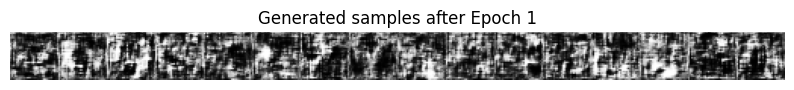

Epoch [1/10] | LC: -253.579 | LG: -6777.760 | GP: 6.402


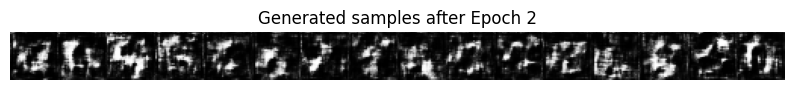

Epoch [2/10] | LC: -392.842 | LG: -12623.444 | GP: 11.571


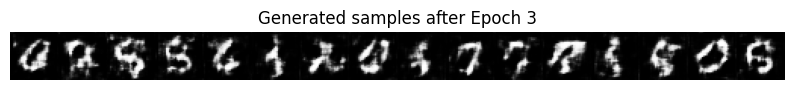

Epoch [3/10] | LC: -904.806 | LG: -15275.854 | GP: 26.533


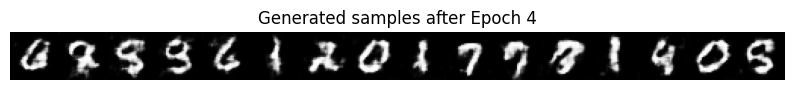

Epoch [4/10] | LC: -1022.636 | LG: -3921.472 | GP: 24.738


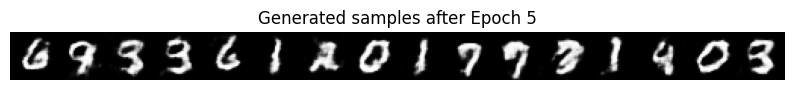

Epoch [5/10] | LC: -743.694 | LG: -16688.719 | GP: 34.664


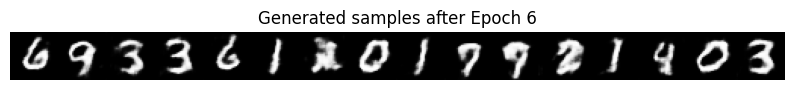

Epoch [6/10] | LC: -927.260 | LG: -15507.313 | GP: 41.095


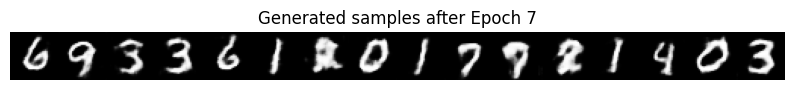

Epoch [7/10] | LC: -915.354 | LG: -2149.832 | GP: 33.098


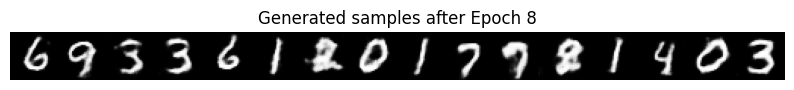

Epoch [8/10] | LC: -662.926 | LG: -14379.764 | GP: 31.900


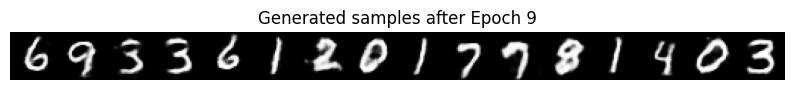

Epoch [9/10] | LC: -797.910 | LG: -9436.969 | GP: 31.137


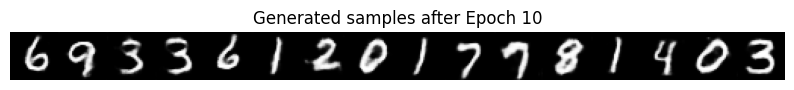

Epoch [10/10] | LC: -623.923 | LG: -9011.675 | GP: 23.915


In [33]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
z_dim = 64
lambda_gp = 10
n_critic = 3
lr = 2e-4
betas = (0.0, 0.9)
epochs = 10

G = Generator(z_dim=z_dim).to(device)
D = Critic().to(device)

opt_G = optim.Adam(G.parameters(), lr=lr, betas=betas)
opt_D = optim.Adam(D.parameters(), lr=lr, betas=betas)

G_ema = deepcopy(G)
for p in G_ema.parameters():
    p.requires_grad_(False)

fixed_z = torch.randn(16, z_dim, device=device)
fixed_y = torch.randint(0, 10, (16,), device=device)

logs = {'real_score': [], 'fake_score': [], 'gp': [], 'loss_C': [], 'loss_G': []}

for epoch in range(epochs):
    for i, (real, y) in enumerate(train_loader):
        real, y = real.to(device), y.to(device)
        B = real.size(0)

        for _ in range(n_critic):
            z = torch.randn(B, z_dim, device=device)
            fake_det = G(z, y).detach()
            real_score = D(real, y).mean()
            fake_score = D(fake_det, y).mean()
            eps = torch.rand(B, 1, 1, 1, device=device)
            x_hat = (eps * real + (1 - eps) * fake_det).requires_grad_(True)
            hat_score = D(x_hat, y).mean()
            grad = torch.autograd.grad(
                outputs=hat_score, inputs=x_hat,
                create_graph=True, retain_graph=True, only_inputs=True
            )[0]
            grad_norm = grad.view(B, -1).norm(2, dim=1)
            gp = ((grad_norm - 1.0) ** 2).mean()
            loss_C = -(real_score - fake_score) + lambda_gp * gp
            opt_D.zero_grad()
            loss_C.backward()
            opt_D.step()

        z = torch.randn(B, z_dim, device=device)
        fake = G(z, y)
        loss_G = -D(fake, y).mean()
        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()
        ema_update(G, G_ema, decay=0.999)
        logs['real_score'].append(real_score.item())
        logs['fake_score'].append(fake_score.item())
        logs['gp'].append(gp.item())
        logs['loss_C'].append(loss_C.item())
        logs['loss_G'].append(loss_G.item())

    with torch.no_grad():
        fake_samples = G_ema(fixed_z, fixed_y)
        grid = torch.cat([f for f in fake_samples.cpu()],dim=2)
        plt.figure(figsize=(10,2))
        plt.imshow(grid.squeeze(), cmap='gray')
        plt.axis('off')
        plt.title(f"Generated samples after Epoch {epoch+1}")
        plt.show()

    print(f"Epoch [{epoch+1}/{epochs}] | LC: {loss_C.item():.3f} | LG: {loss_G.item():.3f} | GP: {gp.item():.3f}")


Plot curves for: E[D(x, y)], E[D(G(z, y), y)], GP, LC, LG

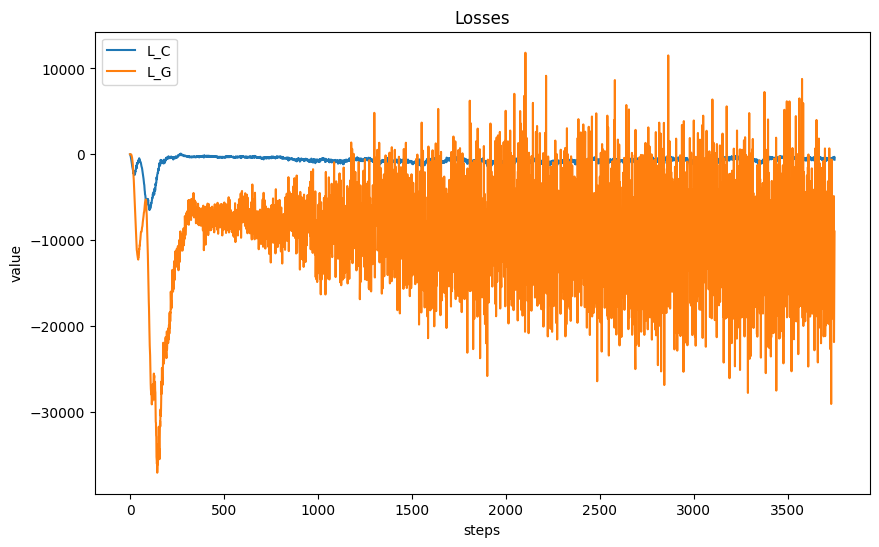

In [34]:
plt.figure(figsize=(10, 6))
plt.plot(logs['loss_C'], label='L_C')
plt.plot(logs['loss_G'], label='L_G')
plt.legend()
plt.xlabel('steps')
plt.ylabel('value')
plt.title('Losses')
plt.show()

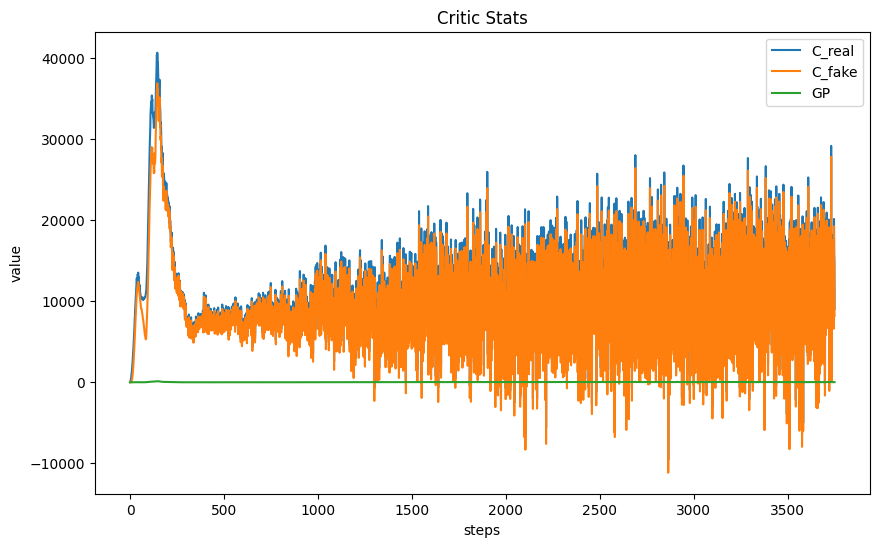

In [35]:
plt.figure(figsize=(10, 6))
plt.plot(logs['real_score'], label='C_real')
plt.plot(logs['fake_score'], label='C_fake')
plt.plot(logs['gp'], label='GP')
plt.legend()
plt.xlabel('steps')
plt.ylabel('value')
plt.title('Critic Stats')
plt.show()

## Part 3: Conditional Samples ##

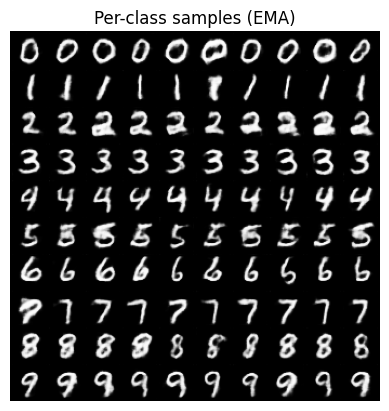

In [36]:
G_ema.eval()
num_classes = 10
samples_per_class = 10

z = torch.randn(num_classes * samples_per_class, z_dim, device=device)
labels = torch.arange(num_classes, device=device).repeat_interleave(samples_per_class)

with torch.no_grad():
    fake_images = G_ema(z, labels)

grid = make_grid(fake_images, nrow=samples_per_class, normalize=True)
plt.imshow(grid.permute(1, 2, 0).cpu())
plt.axis('off')
plt.title("Per-class samples (EMA)")
plt.show()
save_image(grid, "conditional_samples.png")

## Part 4: Latent Exploration and Truncation ##

Latent interpolations for all digits: for each class c ∈ {0, . . . , 9}, interpolate z between two random endpoints and show a row of K images. Aggregate into a 10 × K panel.

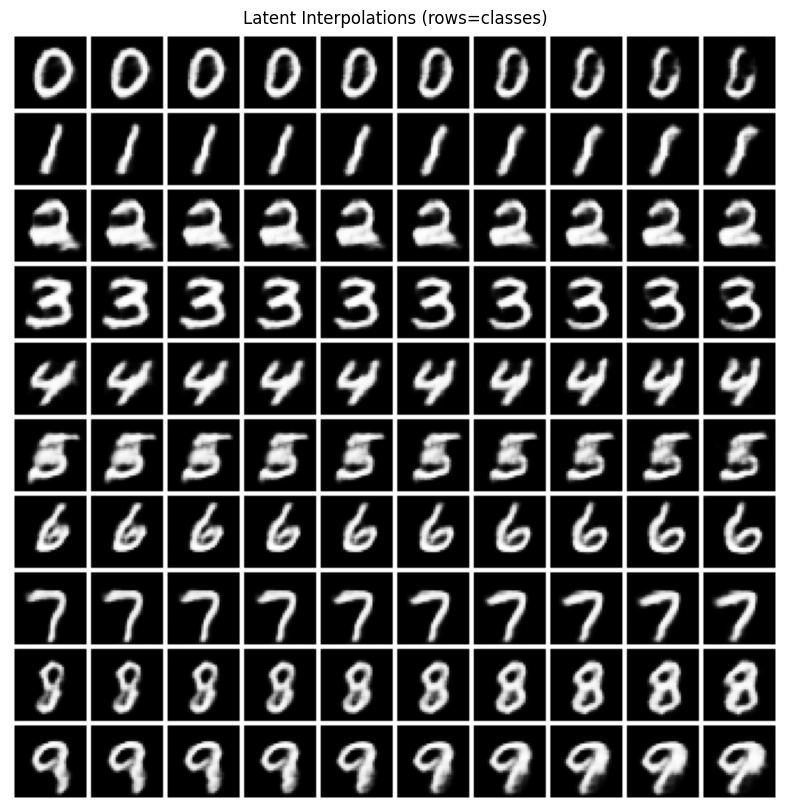

In [38]:
K = 10
device = next(G_ema.parameters()).device
G_ema.eval()
rows = []

with torch.no_grad():
    for c in range(num_classes):
        rand_endpoint1 = torch.randn(1, z_dim, device=device)
        rand_endpoint2 = torch.randn(1, z_dim, device=device)
        alphas = torch.linspace(0, 1, K, device=device).unsqueeze(1)
        z_interp = (1 - alphas) * rand_endpoint1 + alphas * rand_endpoint2
        labels = torch.full((K,), c, dtype=torch.long, device=device)
        fake_images = G_ema(z_interp, labels)
        fake_images = (fake_images + 1) / 2
        rows.append(fake_images)

all_images = torch.cat(rows, dim=0)
grid = make_grid(all_images, nrow=K, normalize=False, pad_value=1.0)

plt.figure(figsize=(K, num_classes))
plt.imshow(grid.permute(1, 2, 0).cpu())
plt.axis('off')
plt.title("Latent Interpolations (rows=classes)")
plt.show()
save_image(grid, "latent_interpolations_ema.png")

Truncation sweep: for each class, generate samples by scaling z ← ψz with ψ ∈ {3.0, 2.5, 2.0, 1.5, 1.0, 0.8, 0.6, 0.4, 0.2, 0.1}.

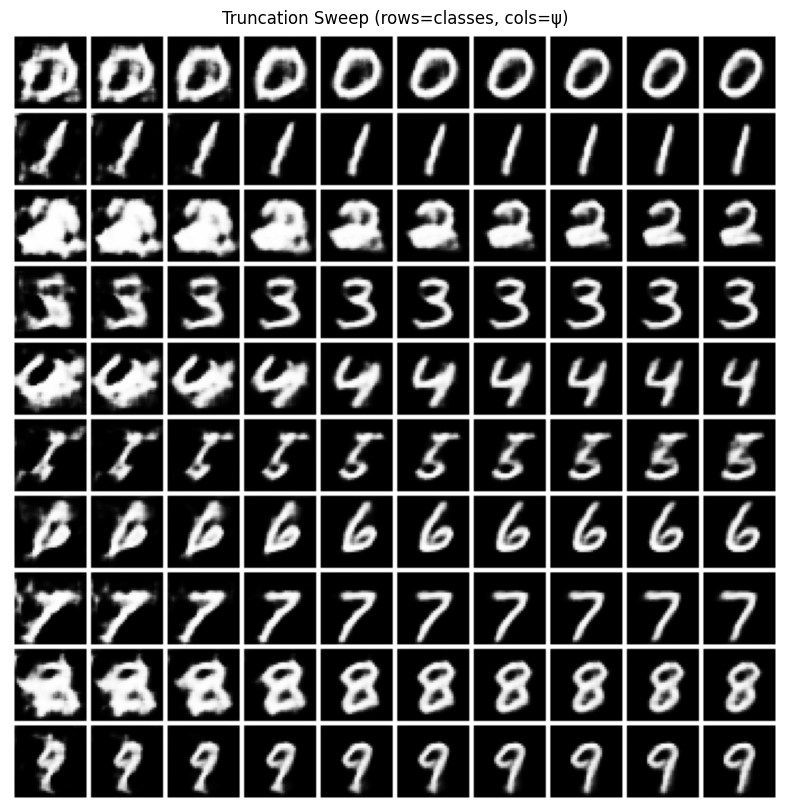

In [39]:
spsi_values = [3.0, 2.5, 2.0, 1.5, 1.0, 0.8, 0.6, 0.4, 0.2, 0.1]
device = next(G_ema.parameters()).device
G_ema.eval()
rows = []

with torch.no_grad():
    for c in range(num_classes):
        z_base = torch.randn(1, z_dim, device=device)
        z_scaled = torch.cat([psi * z_base for psi in psi_values], dim=0)
        labels = torch.full((len(psi_values),), c, dtype=torch.long, device=device)
        fake_images = G_ema(z_scaled, labels)
        fake_images = (fake_images + 1) / 2
        rows.append(fake_images)

all_images = torch.cat(rows, dim=0)
grid = make_grid(all_images, nrow=len(psi_values), normalize=False, pad_value=1.0)
plt.figure(figsize=(len(psi_values), num_classes))
plt.imshow(grid.permute(1, 2, 0).cpu(), cmap='gray')
plt.axis('off')
plt.title("Truncation Sweep (rows=classes, cols=ψ)")
plt.show()
save_image(grid, "truncation_sweep_ema.png")